# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [24]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

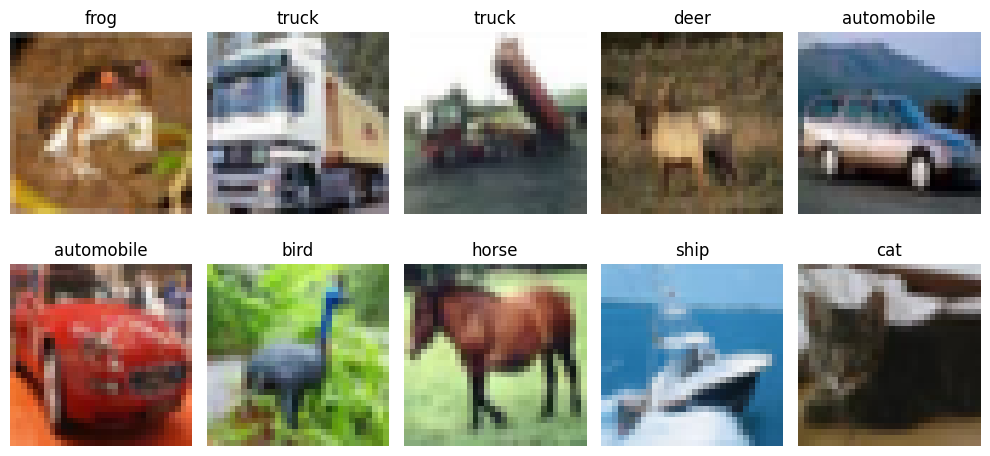

In [25]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [26]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [27]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),   # ← new layer
    layers.Dropout(0.2),                    # ← new dropout
    layers.Dense(64, activation='relu'),    # ← new layer
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2148 - loss: 2.0790 - val_accuracy: 0.2820 - val_loss: 1.9268
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.2782 - loss: 1.9486 - val_accuracy: 0.3308 - val_loss: 1.8555
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2975 - loss: 1.9061 - val_accuracy: 0.3082 - val_loss: 1.8684
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.3076 - loss: 1.8788 - val_accuracy: 0.3466 - val_loss: 1.8211
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3140 - loss: 1.8615 - val_accuracy: 0.3536 - val_loss: 1.8079
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.3174 - loss: 1.8521 - val_accuracy: 0.3604 - val_loss: 1.7781
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3206 - loss: 1.8442 - val_accuracy: 0.3420 - val_loss: 1.8040
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.3258 - loss: 1.8289 - 

In [28]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4024 - loss: 1.6830
ANN Test Accuracy: 0.4023999869823456


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [29]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 116ms/step - accuracy: 0.4765 - loss: 1.4660 - val_accuracy: 0.4456 - val_loss: 1.5519
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6093 - loss: 1.1123 - val_accuracy: 0.5542 - val_loss: 1.2805
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.6707 - loss: 0.9463 - val_accuracy: 0.6174 - val_loss: 1.1870
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.7082 - loss: 0.8296 - val_accuracy: 0.6726 - val_loss: 0.9493
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7429 - loss: 0.7360 - val_accuracy: 0.5860 - val_loss: 1.2243
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7715 - loss: 0.6521 - val_accuracy: 0.6998 - val_loss: 0.9065
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 116ms/step - accuracy: 0.7942 - loss: 0.5833 - val_accuracy: 0.7022 - val_loss: 0.9034
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.8150 - loss: 

In [30]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7247 - loss: 0.9598
CNN Test Accuracy: 0.7246999740600586


## 📈 Compare Learning Curves

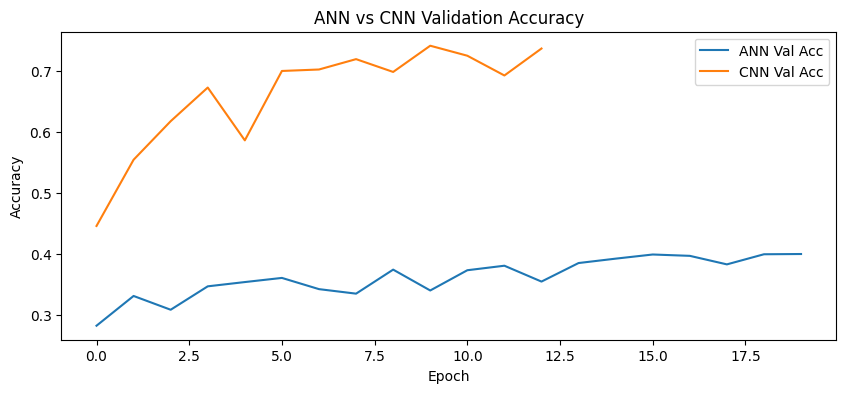

In [31]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

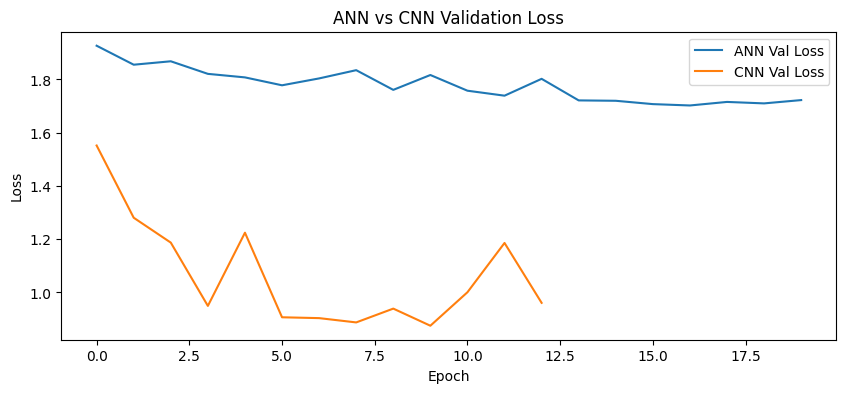

In [38]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_loss'], label='ANN Val Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN vs CNN Validation Loss")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [36]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 92ms/step - accuracy: 0.3861 - loss: 1.6972 - val_accuracy: 0.4668 - val_loss: 1.4882
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 90ms/step - accuracy: 0.4794 - loss: 1.4537 - val_accuracy: 0.5648 - val_loss: 1.2246
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 93ms/step - accuracy: 0.5196 - loss: 1.3546 - val_accuracy: 0.5950 - val_loss: 1.1523
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.5457 - loss: 1.2879 - val_accuracy: 0.6096 - val_loss: 1.1081
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.5620 - loss: 1.2408 - val_accuracy: 0.6146 - val_loss: 1.1033
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5731 - loss: 1.2091 - val_accuracy: 0.6308 - val_loss: 1.0356
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.5817 - loss: 1.1845 - val_accuracy: 0.6174 - val_loss: 1.1055
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5891 - loss: 1.1630 - 

# 📊 Final Comparison Table

In [37]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4024
1,CNN,0.7247
2,Augmented CNN,0.6865


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**